In [1]:
import os
import sys


def find_project_root(marker="src") -> str:
    """Walk up from the current directory until a folder containing `marker` is found."""
    path = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find a parent folder containing '{marker}'")
        path = parent


sys.path.append(find_project_root())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import load_merged_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 1000)

df = load_merged_dataset()
df.head(12)

[*********************100%***********************]  8 of 8 completed


,ONI,cocoa_price,usd_index,gold_price,coffee_price,natural_gas_price,soybean_price,wheat_price,us_interest_rate
Date,,,,,,,,,
2000-09-01,-0.42,797.0,0.79428,273.600006,83.000000,5.200,499.00,258.00,6.03
2000-10-01,-0.54,755.0,0.79428,264.899994,74.400002,4.500,455.25,253.50,6.15
2000-11-01,-0.76,704.0,0.79428,270.100006,67.199997,6.580,502.00,252.50,6.01
2000-12-01,-0.78,758.0,0.79428,272.000000,65.550003,9.775,499.00,272.75,5.73
2001-01-01,-0.76,1020.0,0.79428,265.600006,63.750000,5.650,459.75,271.00,4.84
2001-02-01,-0.54,1131.0,0.79428,266.799988,63.900002,5.245,454.75,257.50,4.72
2001-03-01,-0.43,1073.0,0.79428,257.899994,60.299999,5.030,436.00,265.00,4.18
2001-04-01,-0.29,1010.0,0.79428,264.000000,61.849998,4.695,422.00,265.75,3.83
2001-05-01,-0.19,936.0,0.79428,265.299988,57.150002,3.914,438.00,264.75,3.54


In [2]:
df.tail(6)

,ONI,cocoa_price,usd_index,gold_price,coffee_price,natural_gas_price,soybean_price,wheat_price,us_interest_rate
Date,,,,,,,,,
2026-02-01,-0.21,2798.0,0.84724,5230.500000,284.600006,2.859,1157.25,591.25,3.578
2026-03-01,0.11,3300.0,0.87260,4647.600098,298.350006,2.884,1171.00,616.25,3.600
2026-04-01,0.46,3494.0,0.85582,4614.700195,300.899994,2.767,1182.00,623.75,3.585
2026-05-01,0.95,3923.0,0.85816,4560.500000,265.600006,3.290,1186.75,610.50,3.588
2026-06-01,1.39,5002.0,0.87550,4022.899902,311.200012,3.275,1116.75,580.75,3.732
2026-07-01,1.80,5397.0,0.86779,4049.100098,332.100006,2.747,1172.00,639.25,3.682


In [3]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nImportant Statistics:")
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 311 entries, 2000-09-01 to 2026-07-01
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ONI                311 non-null    float64
 1   cocoa_price        311 non-null    float64
 2   usd_index          311 non-null    float64
 3   gold_price         311 non-null    float64
 4   coffee_price       311 non-null    float64
 5   natural_gas_price  311 non-null    float64
 6   soybean_price      311 non-null    float64
 7   wheat_price        311 non-null    float64
 8   us_interest_rate   311 non-null    float64
dtypes: float64(9)
memory usage: 24.3 KB

Missing Values:
ONI                  0
cocoa_price          0
usd_index            0
gold_price           0
coffee_price         0
natural_gas_price    0
soybean_price        0
wheat_price          0
us_interest_rate     0
dtype: int64

Important Statistics:


,ONI,cocoa_price,usd_index,gold_price,coffee_price,natural_gas_price,soybean_price,wheat_price,us_interest_rate
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,0.022733,2805.128617,0.821023,1327.512861,147.969614,4.392814,1011.667203,538.324759,1.810614
std,0.780693,1795.649022,0.078390,877.601891,74.403901,2.210228,325.969181,173.397980,1.847456
min,-1.760000,704.000000,0.634600,257.899994,42.599998,1.640000,422.000000,244.750000,0.003000
25%,-0.500000,1942.500000,0.766405,656.500000,104.625000,2.807000,833.500000,409.750000,0.097500
50%,-0.080000,2416.000000,0.812820,1252.599976,127.449997,3.730000,995.750000,526.250000,1.202000
75%,0.505000,2951.000000,0.889790,1713.300049,178.299995,5.404000,1274.750000,648.125000,3.566000
max,2.590000,11675.000000,1.017340,5230.500000,413.600006,13.921000,1764.500000,1087.500000,6.150000


## 1. Prices vs Oceanic Niño Index (ONI)

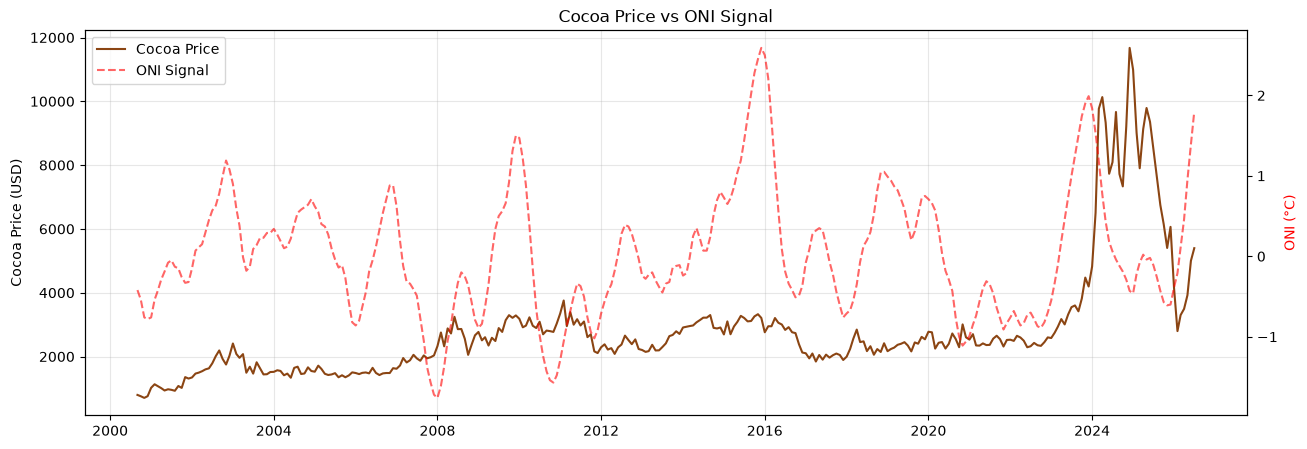

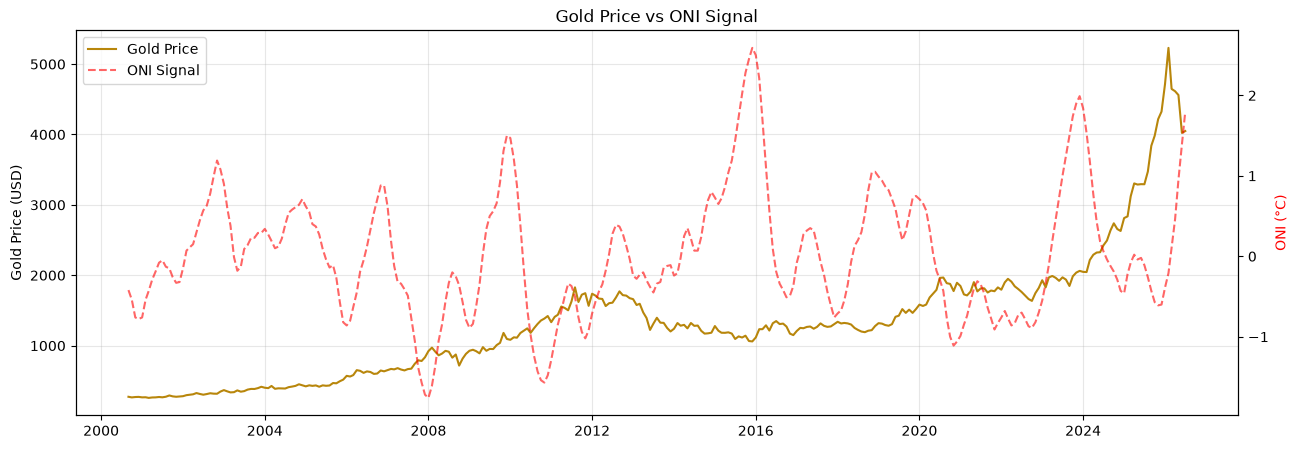

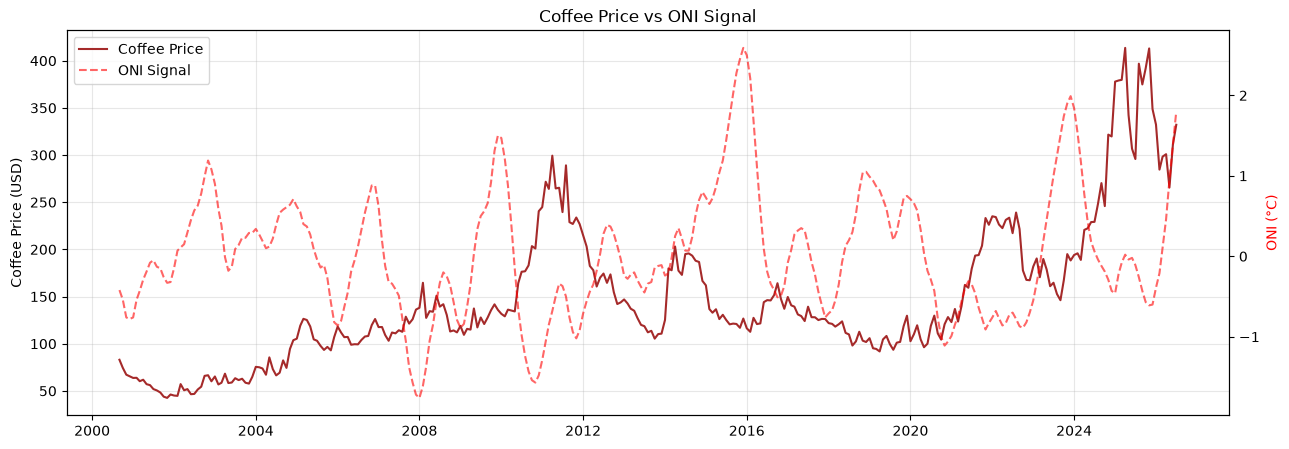

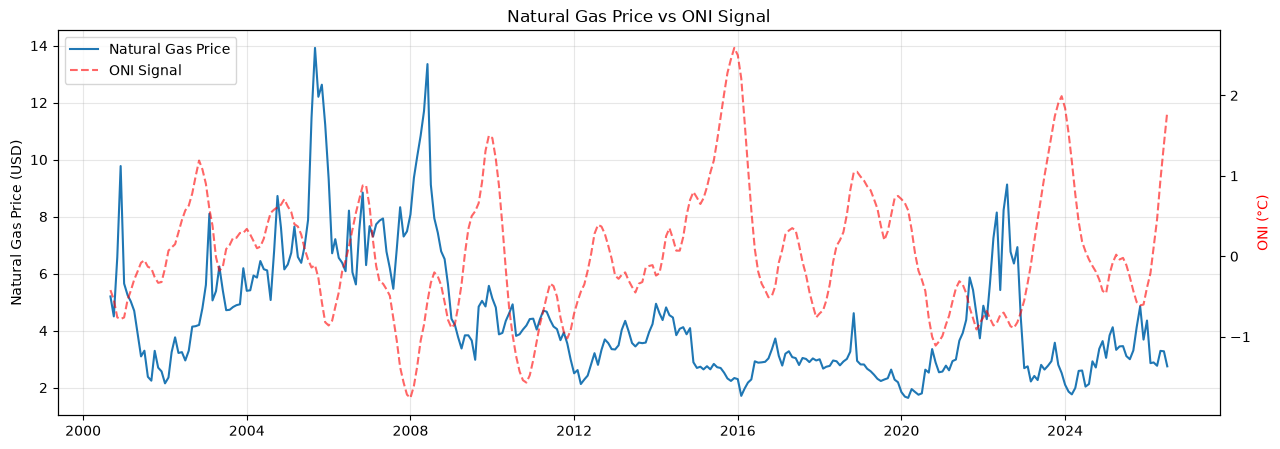

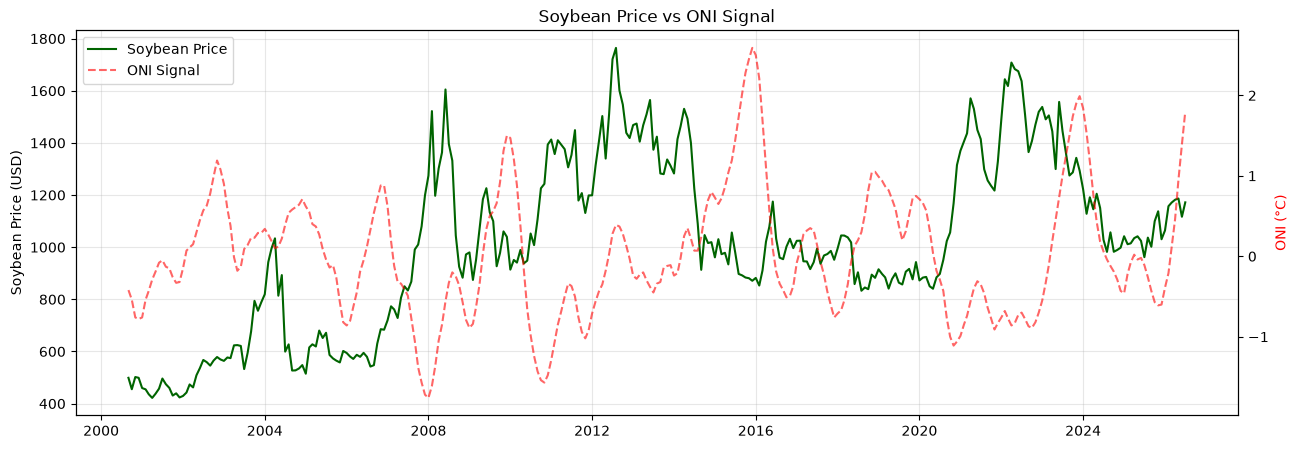

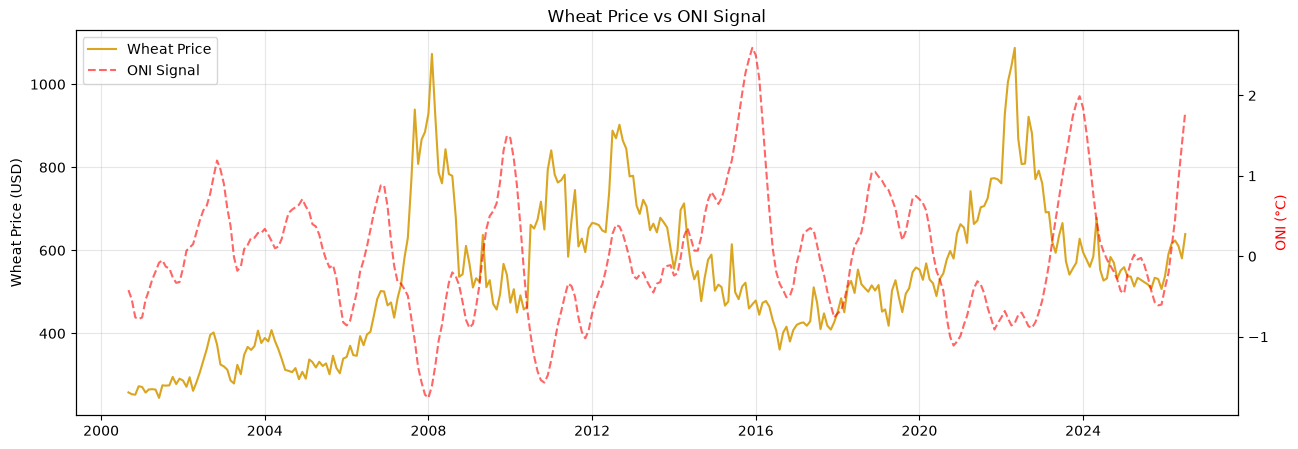

In [4]:
commodities = {
    "cocoa_price": ("Cocoa Price", "saddlebrown"),
    "gold_price": ("Gold Price", "darkgoldenrod"),
    "coffee_price": ("Coffee Price", "brown"),
    "natural_gas_price": ("Natural Gas Price", "tab:blue"),
    "soybean_price": ("Soybean Price", "darkgreen"),
    "wheat_price": ("Wheat Price", "goldenrod"),
}

for commodity, (display_name, line_color) in commodities.items():
    fig, axis = plt.subplots(figsize=(15, 5))

    axis.plot(df.index, df[commodity], color=line_color, label=display_name)
    axis.set_ylabel(f"{display_name} (USD)")

    oni_axis = axis.twinx()
    oni_axis.plot(
        df.index,
        df["ONI"],
        color="red",
        linestyle="--",
        alpha=0.6,
        label="ONI Signal",
    )
    oni_axis.set_ylabel("ONI (°C)", color="red")

    axis.set_title(f"{display_name} vs ONI Signal")
    axis.grid(True, alpha=0.3)

    lines1, labels1 = axis.get_legend_handles_labels()
    lines2, labels2 = oni_axis.get_legend_handles_labels()
    axis.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.show()

## 2. Log returns vs El Nino

[*********************100%***********************]  8 of 8 completed


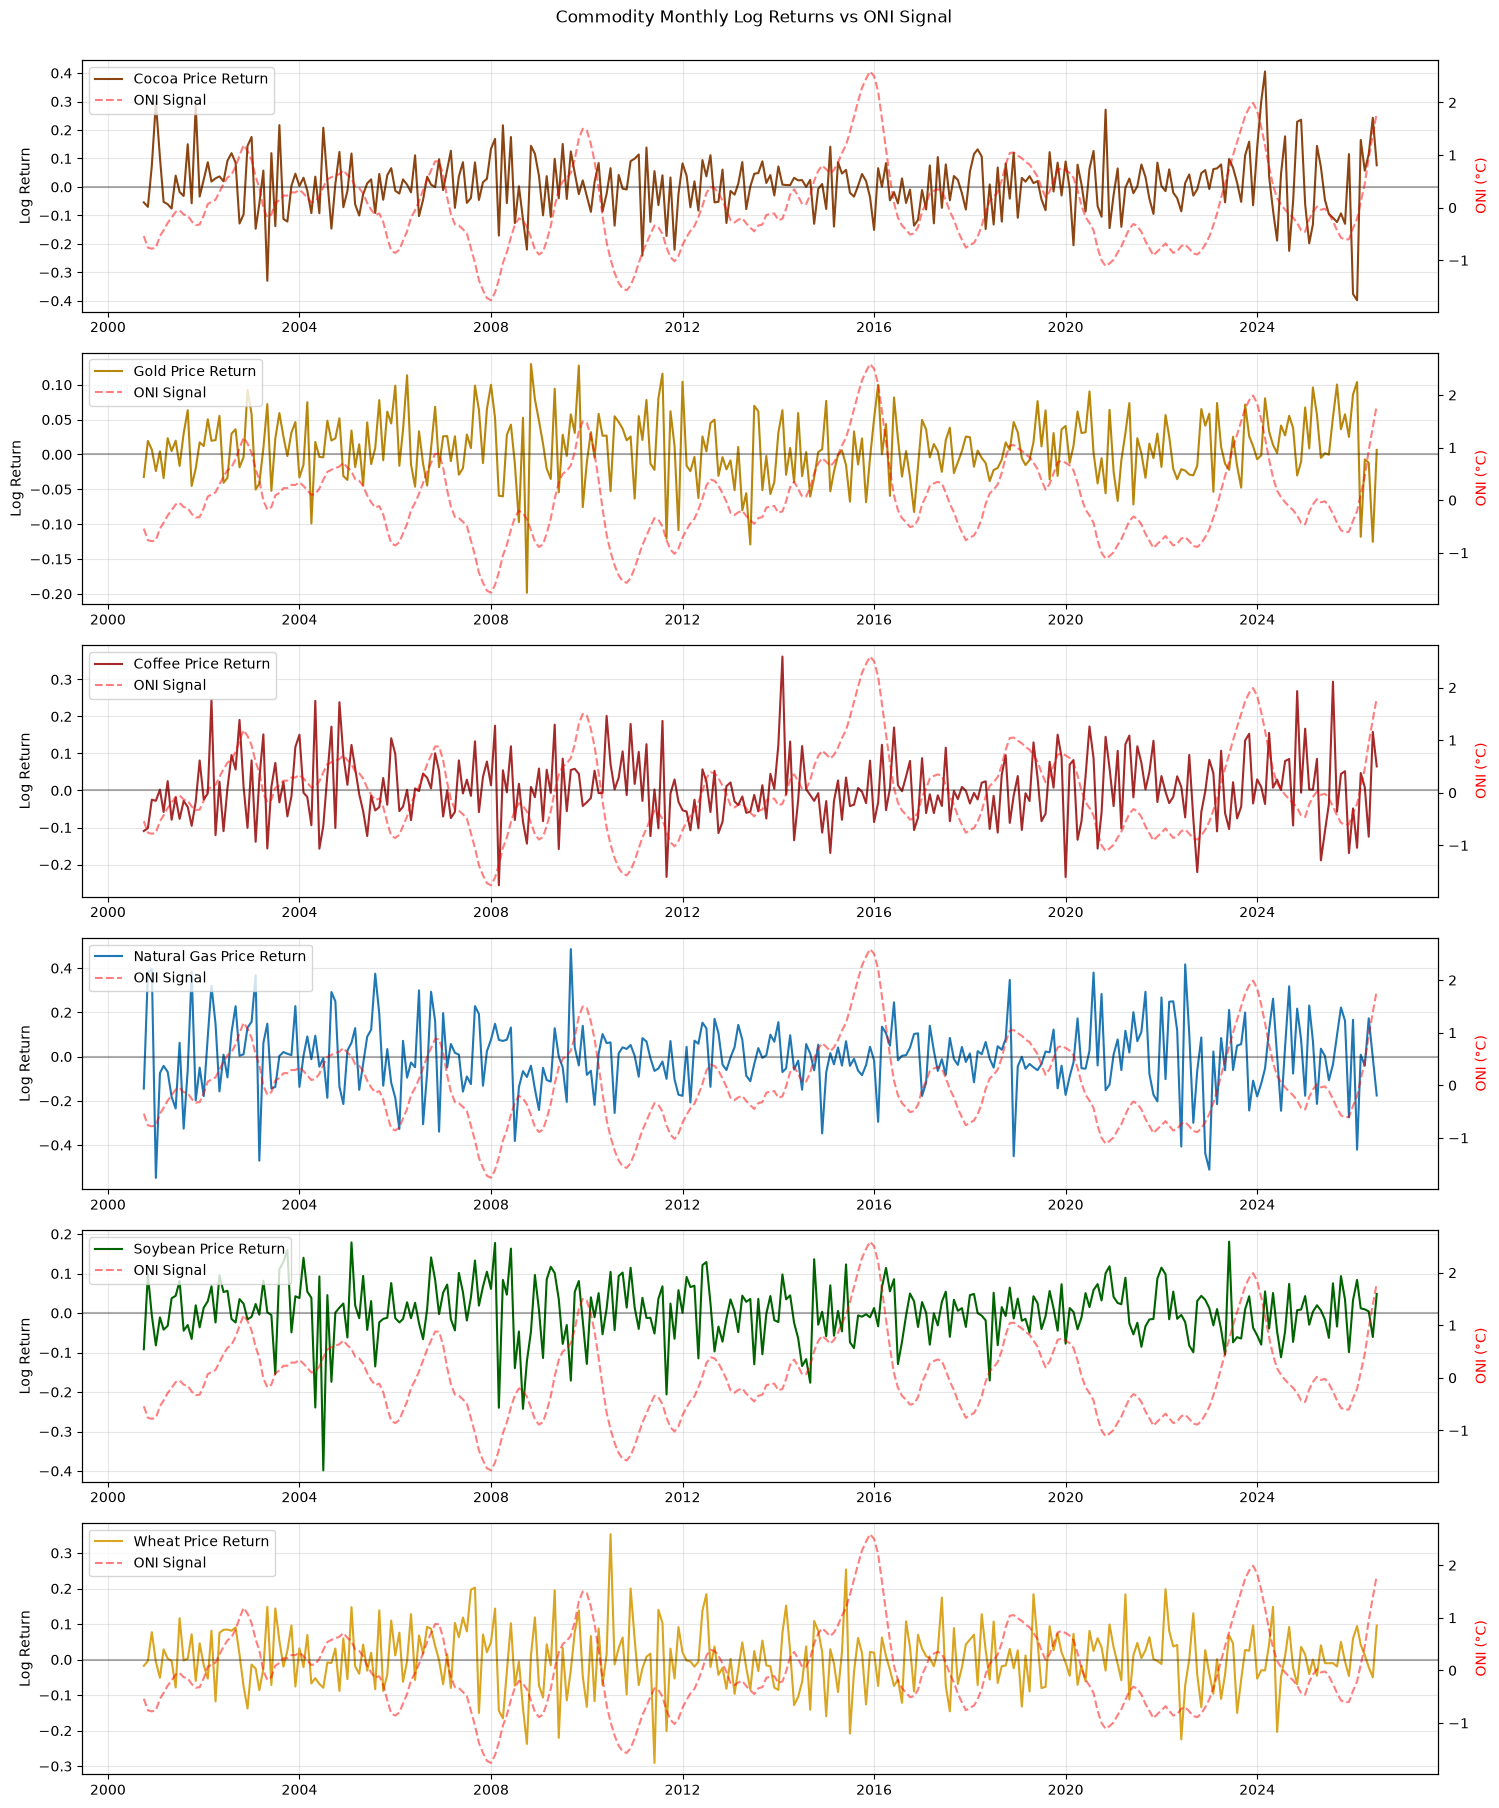

In [5]:
df = load_merged_dataset()

commodities = {
    "cocoa_price": ("Cocoa Price", "saddlebrown"),
    "gold_price": ("Gold Price", "darkgoldenrod"),
    "coffee_price": ("Coffee Price", "brown"),
    "natural_gas_price": ("Natural Gas Price", "tab:blue"),
    "soybean_price": ("Soybean Price", "darkgreen"),
    "wheat_price": ("Wheat Price", "goldenrod"),
}

df_returns = df.copy()

for commodity in commodities:
    df_returns[f"{commodity}_log_return"] = np.log(
        df_returns[commodity] / df_returns[commodity].shift(1)
    )

fig, axes = plt.subplots(len(commodities), 1, figsize=(15, 18))

for axis, (commodity, (display_name, line_color)) in zip(
    axes, commodities.items()
):
    ret_col = f"{commodity}_log_return"
    valid_data = df_returns[[ret_col, "ONI"]].dropna()

    axis.plot(
        valid_data.index,
        valid_data[ret_col],
        color=line_color,
        label=f"{display_name} Return",
    )
    axis.set_ylabel("Log Return")
    axis.axhline(0, color="black", alpha=0.3)
    axis.grid(True, alpha=0.3)

    oni_axis = axis.twinx()
    oni_axis.plot(
        valid_data.index,
        valid_data["ONI"],
        color="red",
        linestyle="--",
        alpha=0.5,
        label="ONI Signal",
    )
    oni_axis.set_ylabel("ONI (°C)", color="red")

    lines1, labels1 = axis.get_legend_handles_labels()
    lines2, labels2 = oni_axis.get_legend_handles_labels()
    axis.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle("Commodity Monthly Log Returns vs ONI Signal", y=1.002)
plt.tight_layout()
plt.show()

## 3. Macro Regimes Analysis

We split the 2000–2026 dataset into 4 macroeconomic periods:

* (2000–2012): Commodity Boom & Financial Crisis (R1)
* (2013–2019): Low Interest Rate Era (R2)
* (2020–2022): COVID Era (R3)
* (2023–2026): Inflation & Climate Events (R4)

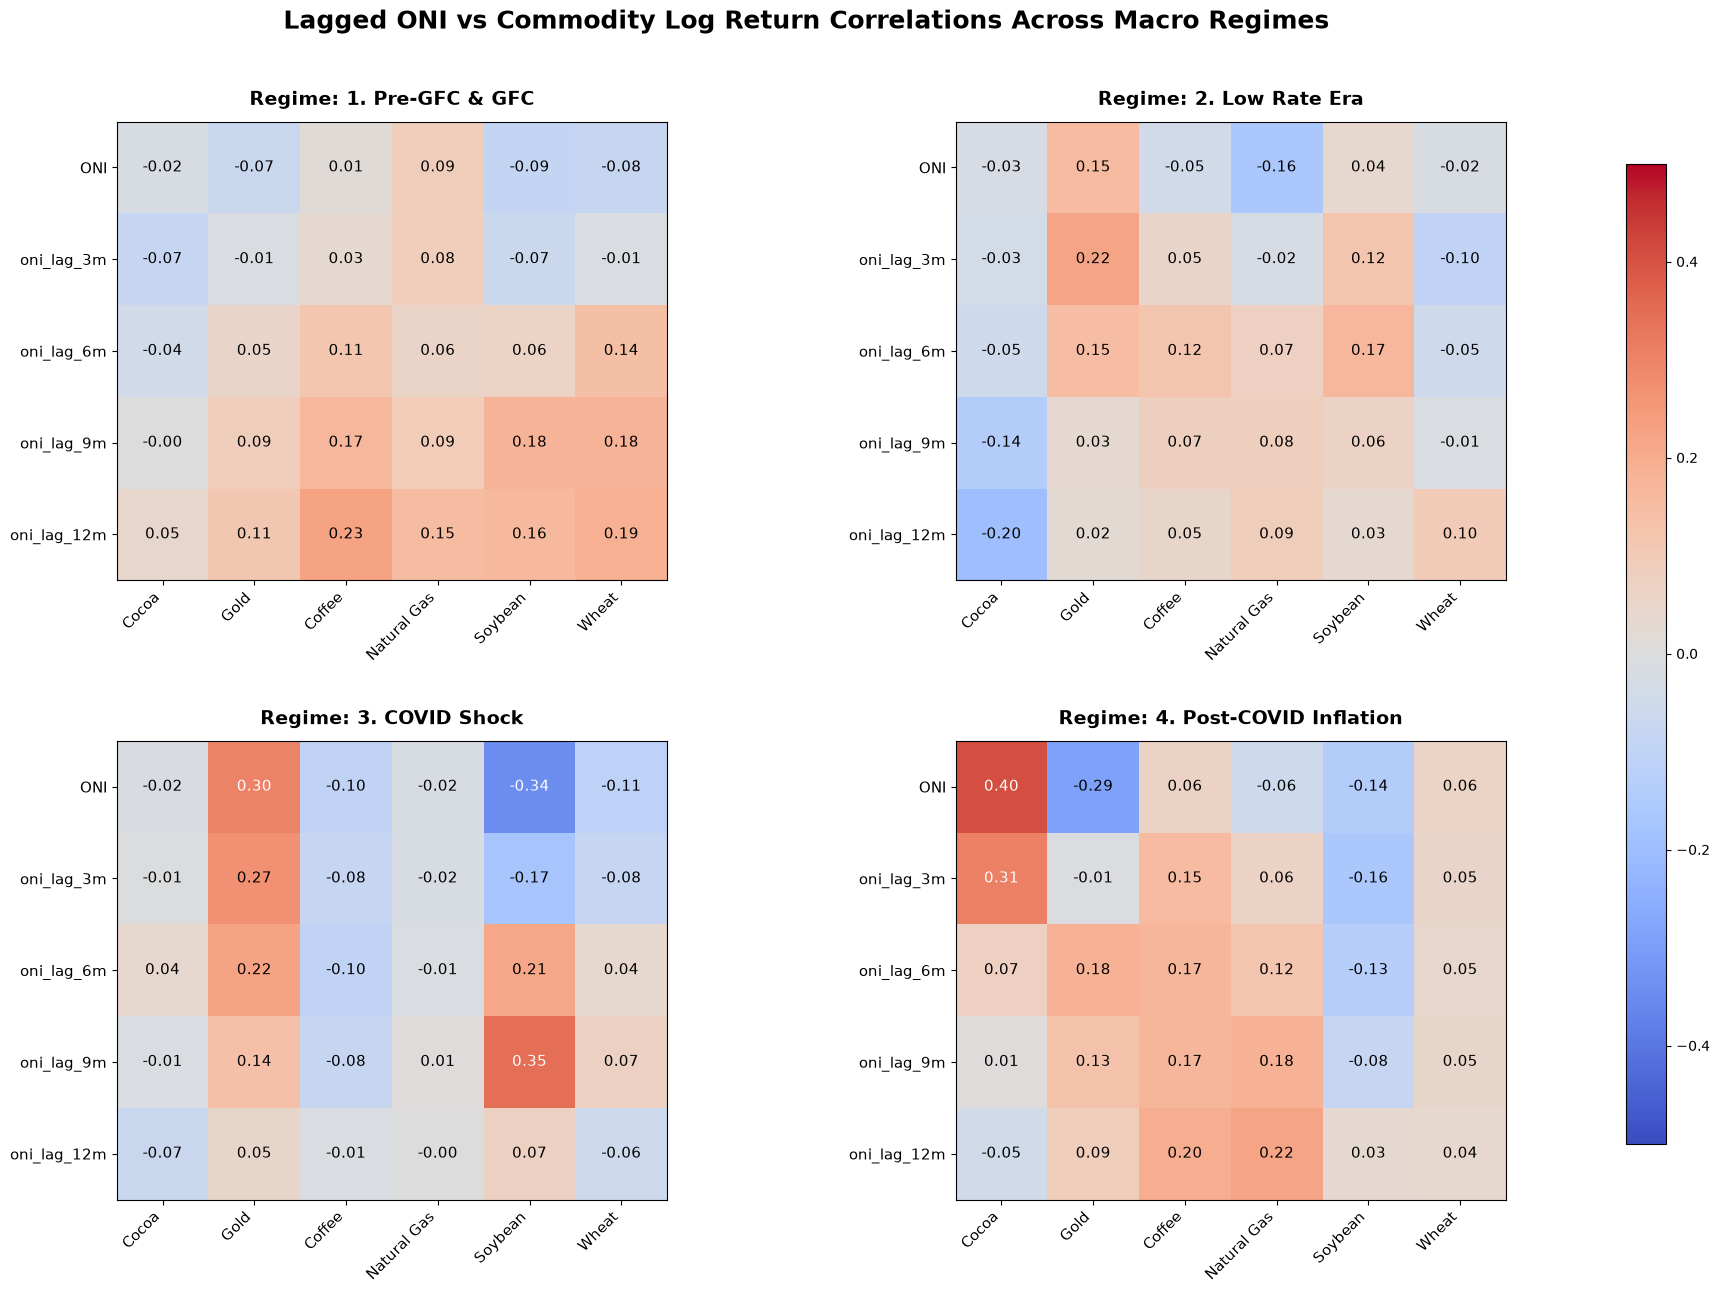

In [6]:
df_macro = df_returns.copy()

lags = [3, 6, 9, 12]
for lag in lags:
    df_macro[f"oni_lag_{lag}m"] = df_macro["ONI"].shift(lag)

conditions = [
    (df_macro.index >= "2000-09-01") & (df_macro.index <= "2012-12-31"),
    (df_macro.index >= "2013-01-01") & (df_macro.index <= "2019-12-31"),
    (df_macro.index >= "2020-01-01") & (df_macro.index <= "2022-12-31"),
    (df_macro.index >= "2023-01-01"),
]
regime_names = ["1. Pre-GFC & GFC", "2. Low Rate Era", "3. COVID Shock", "4. Post-COVID Inflation"]

df_macro["macro_regime"] = np.select(conditions, regime_names, default="Other")

return_cols = [f"{col}_log_return" for col in commodities]
oni_cols = ["ONI"] + [f"oni_lag_{lag}m" for lag in lags]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, regime in enumerate(regime_names):
    ax = axes[idx]
    df_sub = df_macro[df_macro["macro_regime"] == regime]
    
    corr_sub = df_sub[oni_cols + return_cols].corr().loc[oni_cols, return_cols]
    
    cax = ax.imshow(corr_sub.values, cmap="coolwarm", vmin=-0.5, vmax=0.5)
    
    for i in range(len(oni_cols)):
        for j in range(len(return_cols)):
            val = corr_sub.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if abs(val) > 0.3 else "black", fontsize=11)
            
    ax.set_xticks(range(len(return_cols)))
    ax.set_xticklabels([c.replace("_price_log_return", "").replace("_log_return", "").replace("_", " ").title() for c in return_cols], rotation=45, ha="right", fontsize=11)
    ax.set_yticks(range(len(oni_cols)))
    ax.set_yticklabels(oni_cols, fontsize=11)
    ax.set_title(f"Regime: {regime}", fontsize=14, fontweight="bold", pad=12)

fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.25)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(cax, cax=cbar_ax)

plt.suptitle("Lagged ONI vs Commodity Log Return Correlations Across Macro Regimes", fontsize=18, fontweight="bold", y=0.96)
plt.show()

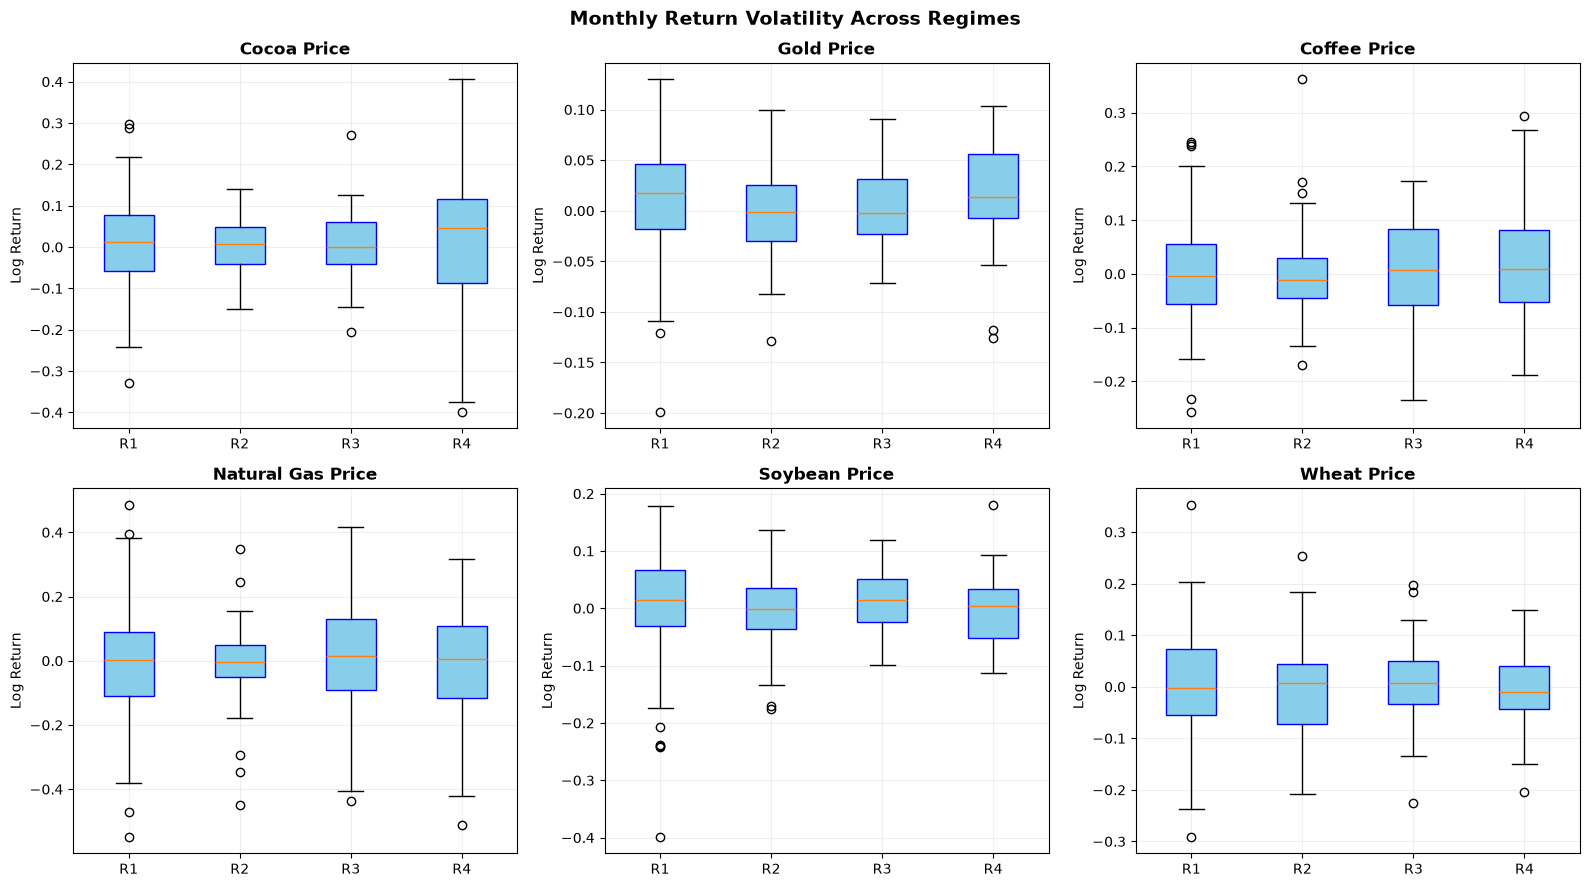

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(commodities):
    axis = axes[idx]
    return_column = f"{col}_log_return"
    
    returns_by_regime = [df_macro[df_macro["macro_regime"] == r][return_column].dropna().values for r in regime_names]
    
    axis.boxplot(returns_by_regime, patch_artist=True, boxprops={"facecolor": "skyblue", "color": "blue"})
    axis.set_title(commodities[col][0], fontweight="bold")
    axis.set_xticklabels(["R1", "R2", "R3", "R4"])
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.2)

plt.suptitle("Monthly Return Volatility Across Regimes", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

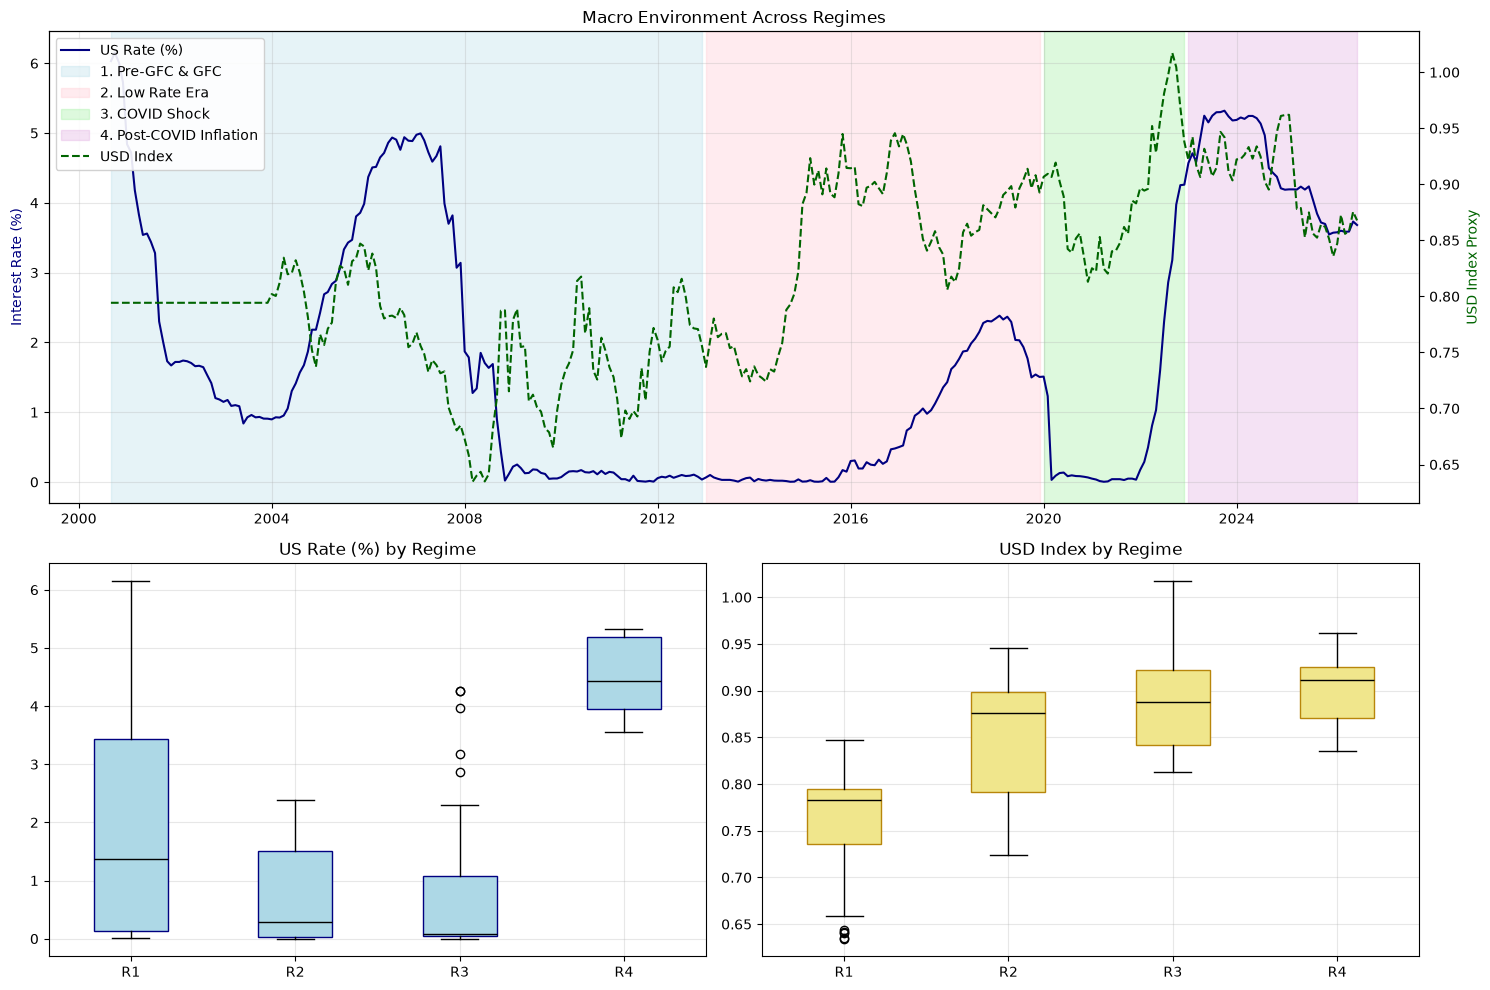

In [8]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = ax1.twinx()

ax1.plot(df_macro.index, df_macro["us_interest_rate"], color="navy", label="US Rate (%)")

usd_valid = df_macro["usd_index"].dropna()
ax2.plot(usd_valid.index, usd_valid, color="darkgreen", linestyle="--", label="USD Index")

ax1.set_ylabel("Interest Rate (%)", color="navy")
ax2.set_ylabel("USD Index Proxy", color="darkgreen")

colors = ["lightblue", "pink", "lightgreen",  "plum"]

for regime, col in zip(regime_names, colors):
    sub = df_macro[df_macro["macro_regime"] == regime]
    if not sub.empty:
        ax1.axvspan(sub.index.min(), sub.index.max(), color=col, alpha=0.3, label=regime)

ax1.grid(True, alpha=0.3)
ax1.set_title("Macro Environment Across Regimes")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=0.9)

macro_metrics = [
    ("us_interest_rate", "US Rate (%)", "lightblue", "navy"),
    ("usd_index", "USD Index", "khaki", "darkgoldenrod"),
]

for idx, (col, title, facecolor, edgecolor) in enumerate(macro_metrics):
    ax = fig.add_subplot(gs[1, idx])
    data = [df_macro[df_macro["macro_regime"] == r][col].dropna() for r in regime_names]
    
    ax.boxplot(
        data, 
        tick_labels=["R1", "R2", "R3", "R4"], 
        patch_artist=True,
        boxprops={"facecolor": facecolor, "color": edgecolor},
        medianprops={"color": "black"}
    )
    ax.set_title(f"{title} by Regime")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()